## Subagents

A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [1]:
### Basic deep agent
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [21]:
from typing import Literal
from deepagents import create_deep_agent
from tavily import TavilyClient
from langchain_groq import ChatGroq

tavily_client=TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [3]:
def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"]="general",
    include_raw_content:bool=False
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=include_raw_content
    )

In [4]:
research_subagent={
    "name":"research-agent",
    "description":"Used to reasearch more in depth questions",
    "system_prompt":"You are a great researcher",
    "tools":[internet_search],
    "model":"groq:openai/gpt-oss-20b" #Optional, defaults to main agent model
}

subagents=[research_subagent]

In [8]:
agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents,
)

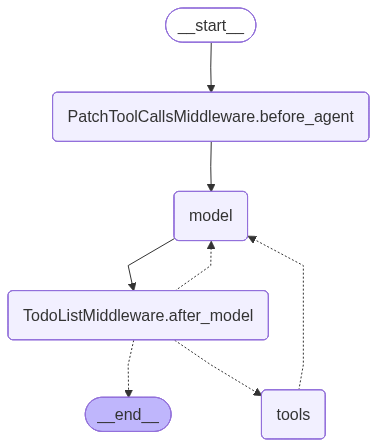

In [9]:
agent

In [10]:
result=agent.invoke({
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Evals and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Evals and provide me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  task (fc_fa67f3b5-af5b-4cdf-98d8-d971de0f864f)
 Call ID: fc_fa67f3b5-af5b-4cdf-98d8-d971de0f864f
  Args:
    description: Conduct comprehensive research on Large Language Model (LLM) evaluations. Include:
- Overview of evaluation categories (intrinsic vs extrinsic, automated vs human)
- Common benchmarks and datasets (e.g., MMLU, HELM, BIG-bench, TruthfulQA, AGIEval, OpenAI Evals, etc.)
- Evaluation metrics (accuracy, BLEU, ROUGE, BLEURT, GPTScore, perplexity, calibration, factuality, toxicity, bias, alignment, safety)
- Recent developments and notable papers (e.g., HELM, OpenAI Evals framework, LLM-as-a-judge, GPTScore, etc.)
- Challenges and best practices (prompt variance, few-shot vs zero-shot, evaluation leakage, model size scaling, human evaluatio

### structured output with subagents

In [18]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task"""
    summary:str=Field(description="Summary of findings")
    confidence:float=Field(description="Confidence score from 0 to 1")
    sources:list[str]=Field(description="List of source URLs")

research_subagent={
    "name":"researcher",
    "description":"Researches topics and returns structured findings",
    "system_prompt":"Research the given topic thoroughly. Return your findings.",
    "tools":[internet_search],
    #"response_format":ResearchFindings
}

In [24]:
research_agent=create_deep_agent(
    model="groq:qwen/qwen3-32b",
    subagents=[research_subagent]
)

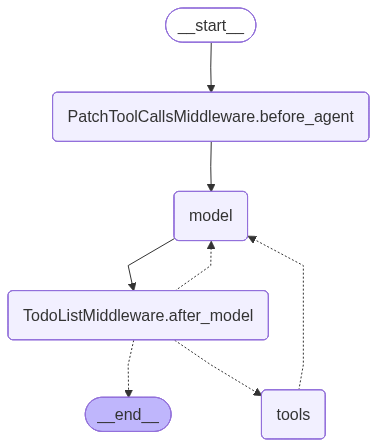

In [25]:
research_agent

In [27]:
result=await research_agent.ainvoke({
    "messages":[{
        "role":"user",
        "content":"Research recent advances in quantum computing"
    }]
})

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01jf87bbe4fnq9jw90kb236hfq` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 6051, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
result

In [ ]:
structurer = ChatGroq(model="openai/gpt-oss-120b").with_structured_output(ResearchFindings)
structured = await structurer.ainvoke(result["messages"][-1].content)

In [ ]:
structured